# Phân Khúc Khách Hàng — (K-Means, DBSCAN, Agglomerative)

## 1. Import thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.metrics import silhouette_score, davies_bouldin_score 
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

## 2. Đọc dữ liệu

In [2]:
df = pd.read_csv(r'C:\Users\khact\Desktop\ML\BTL\papers\method\Customer_Classification\Mall_Customers.csv')
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Hàm tiện ích dùng chung

In [3]:
def euclidean_distance(a, b):
    """Khoảng cách Euclidean giữa hai vector."""
    return np.sqrt(np.sum((a - b) ** 2))


def pairwise_distances(X):
    """Ma trận khoảng cách n × n cho tập dữ liệu X."""
    n = len(X)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = euclidean_distance(X[i], X[j])
            D[i, j] = d
            D[j, i] = d
    return D


def evaluate(X, labels, name):
    """In Silhouette Score và Davies-Bouldin Index."""
    valid = labels != -1
    if len(np.unique(labels[valid])) < 2:
        print(f"{name}: không đủ cụm để đánh giá")
        return
    sil = silhouette_score(X[valid], labels[valid])
    db  = davies_bouldin_score(X[valid], labels[valid])
    n_clusters = len(np.unique(labels[valid]))
    n_noise    = np.sum(labels == -1)
    print(f"{name}: n_clusters={n_clusters}, noise={n_noise}, "
          f"Silhouette={sil:.4f}, Davies-Bouldin={db:.4f}")


def plot_clusters(X, labels, title, xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'):
    plt.figure(figsize=(8, 5))
    unique_labels = np.unique(labels)
    colors = cm.tab10(np.linspace(0, 1, len(unique_labels)))
    for label, color in zip(unique_labels, colors):
        if label == -1:
            color = 'gray'
            marker = 'x'
            lbl = 'Noise'
        else:
            marker = 'o'
            lbl = f'Cluster {label}'
        mask = labels == label
        plt.scatter(X[mask, 0], X[mask, 1], c=[color], marker=marker,
                    s=60, label=lbl, edgecolors='k', linewidths=0.4)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

---
# K-Means 

**Quy trình thuật toán:**
1. Khởi tạo K tâm cụm ngẫu nhiên (chọn k điểm không trùng từ tập dữ liệu)
2. Gán mỗi điểm vào tâm gần nhất
3. Cập nhật tâm = trung bình các điểm trong cụm
4. Lặp đến khi tâm không đổi (hoặc đủ số vòng lặp)

In [4]:
class KMeans:
    def __init__(self, n_clusters=5, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters   = n_clusters
        self.max_iter     = max_iter
        self.tol          = tol
        self.random_state = random_state
        self.centroids_   = None
        self.labels_      = None
        self.inertia_     = None

    # --- Random initialization ---
    def _init_centroids_random(self, X):
        rng = np.random.RandomState(self.random_state)
        indices = rng.choice(len(X), size=self.n_clusters, replace=False)
        return X[indices].copy()

    # --- Gán nhãn ---
    def _assign(self, X):
        labels = np.array([
            np.argmin([euclidean_distance(x, c) for c in self.centroids_])
            for x in X
        ])
        return labels

    # --- Cập nhật tâm ---
    def _update_centroids(self, X, labels):
        new_centroids = np.array([
            X[labels == k].mean(axis=0) if np.sum(labels == k) > 0
            else self.centroids_[k]
            for k in range(self.n_clusters)
        ])
        return new_centroids

    def fit(self, X):
        self.centroids_ = self._init_centroids_random(X)

        for _ in range(self.max_iter):
            labels = self._assign(X)
            new_centroids = self._update_centroids(X, labels)

            # kiểm tra hội tụ
            shift = np.max([euclidean_distance(self.centroids_[k], new_centroids[k])
                            for k in range(self.n_clusters)])
            self.centroids_ = new_centroids
            if shift < self.tol:
                break

        self.labels_  = self._assign(X)
        self.inertia_ = sum(
            euclidean_distance(X[i], self.centroids_[self.labels_[i]]) ** 2
            for i in range(len(X))
        )
        return self

    def fit_predict(self, X):
        return self.fit(X).labels_

### Elbow Method và Silhouette cho K-Means

k=2  inertia=181363.6  sil=0.2969
k=3  inertia=106348.4  sil=0.4676
k=4  inertia=73880.6  sil=0.4938
k=5  inertia=44454.5  sil=0.5532
k=6  inertia=37442.2  sil=0.5368
k=7  inertia=32233.4  sil=0.4544
k=8  inertia=30257.8  sil=0.4387
k=9  inertia=29915.6  sil=0.4097
k=10  inertia=28433.3  sil=0.3872


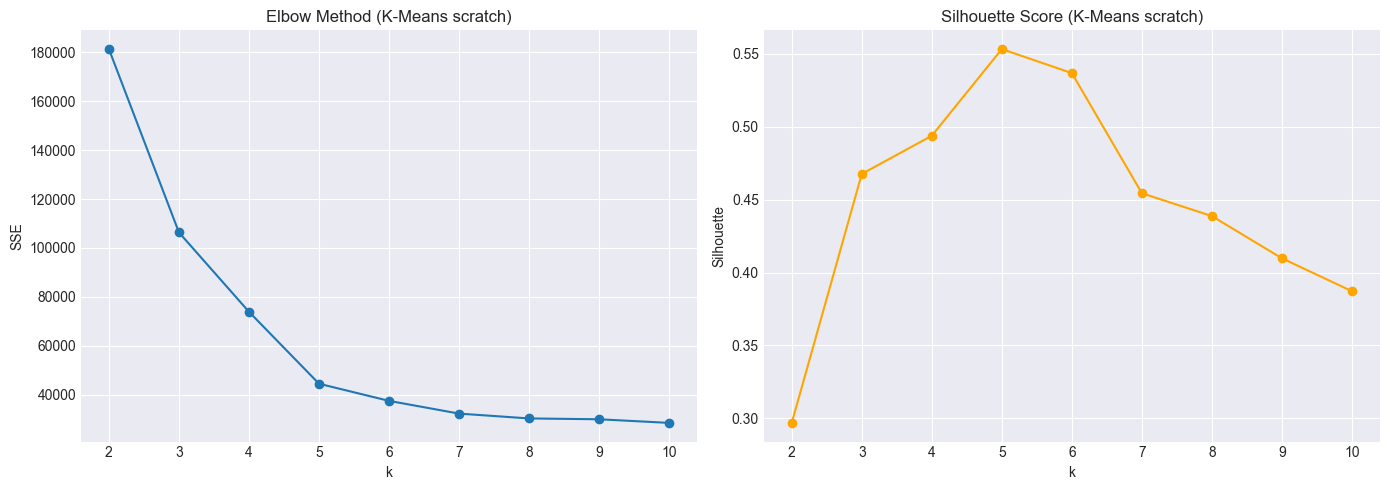

In [5]:
X3 = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

sse_vals = {}
sil_vals = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X3)
    sse_vals[k] = km.inertia_
    sil_vals.append(silhouette_score(X3, km.labels_))
    print(f"k={k}  inertia={km.inertia_:.1f}  sil={sil_vals[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(sse_vals.keys()), list(sse_vals.values()), 'o-')
axes[0].set_title('Elbow Method (K-Means scratch)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('SSE')

axes[1].plot(range(2, 11), sil_vals, 'o-', color='orange')
axes[1].set_title('Silhouette Score (K-Means scratch)')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')

plt.tight_layout(); plt.show()

### Kết quả K-Means (k=5)

K-Means  (Annual Income × Spending Score): n_clusters=5, noise=0, Silhouette=0.5532, Davies-Bouldin=0.5711


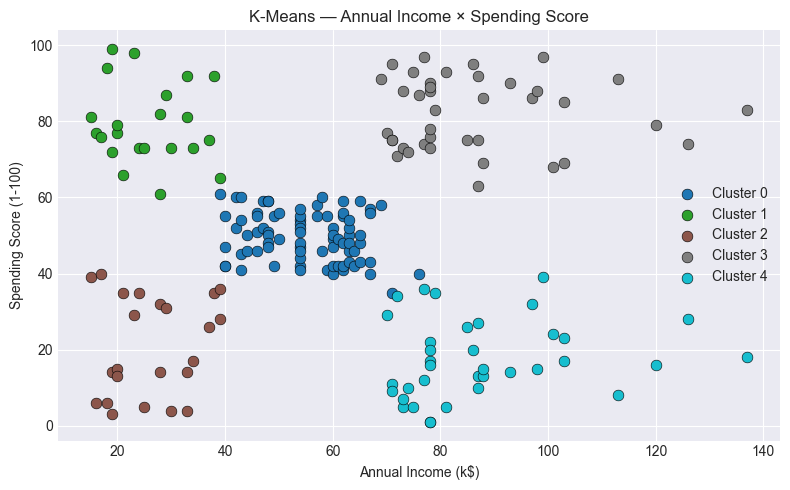

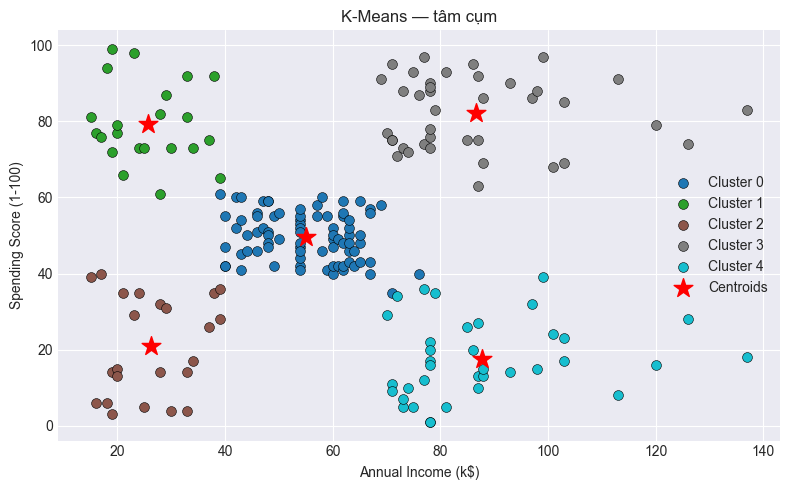

In [6]:
km_best = KMeans(n_clusters=5, random_state=42)
km_best.fit(X3)

evaluate(X3, km_best.labels_, 'K-Means  (Annual Income × Spending Score)')
plot_clusters(X3, km_best.labels_, 'K-Means — Annual Income × Spending Score')

# Vẽ tâm cụm
plt.figure(figsize=(8, 5))
unique_labels = np.unique(km_best.labels_)
colors = cm.tab10(np.linspace(0, 1, len(unique_labels)))
for label, color in zip(unique_labels, colors):
    mask = km_best.labels_ == label
    plt.scatter(X3[mask, 0], X3[mask, 1], c=[color], s=50, label=f'Cluster {label}',
                edgecolors='k', linewidths=0.4)
plt.scatter(km_best.centroids_[:, 0], km_best.centroids_[:, 1],
            c='red', s=200, marker='*', zorder=5, label='Centroids')
plt.title('K-Means — tâm cụm')
plt.xlabel('Annual Income (k$)'); plt.ylabel('Spending Score (1-100)')
plt.legend(); plt.tight_layout(); plt.show()

---
# Agglomerative Hierarchical Clustering Từ Đầu

**Ý tưởng (bottom-up):**
1. Mỗi điểm là một cụm riêng
2. Tìm hai cụm gần nhau nhất (Ward linkage)
3. Gộp chúng lại
4. Lặp đến khi đạt số cụm mong muốn

**Ward linkage:** chọn cặp cụm có tăng phương sai (inertia) nhỏ nhất khi gộp.

In [7]:
class Agglomerative:
    def __init__(self, n_clusters=5, linkage='ward'):
        self.n_clusters = n_clusters
        self.linkage    = linkage   # 'ward' | 'single' | 'complete' | 'average'
        self.labels_    = None
        self.history_   = []        # (step, merged_i, merged_j, distance)

    # --- Chi phí Ward khi gộp hai cụm ---
    @staticmethod
    def _ward_distance(ci, cj):
        ni, nj = len(ci), len(cj)
        mean_i = ci.mean(axis=0)
        mean_j = cj.mean(axis=0)
        return (ni * nj) / (ni + nj) * np.sum((mean_i - mean_j) ** 2)

    @staticmethod
    def _single_distance(ci, cj):
        return min(euclidean_distance(a, b) for a in ci for b in cj)

    @staticmethod
    def _complete_distance(ci, cj):
        return max(euclidean_distance(a, b) for a in ci for b in cj)

    @staticmethod
    def _average_distance(ci, cj):
        dists = [euclidean_distance(a, b) for a in ci for b in cj]
        return np.mean(dists)

    def _cluster_distance(self, ci, cj):
        if self.linkage == 'ward':     return self._ward_distance(ci, cj)
        if self.linkage == 'single':   return self._single_distance(ci, cj)
        if self.linkage == 'complete': return self._complete_distance(ci, cj)
        return self._average_distance(ci, cj)

    def fit_predict(self, X):
        # khởi tạo: mỗi điểm là một cụm
        clusters = {i: X[i:i+1].copy() for i in range(len(X))}
        cluster_ids = list(range(len(X)))  # id hiện tại của từng cụm
        point_cluster = np.arange(len(X))  # nhãn cụm của từng điểm
        next_id = len(X)
        step = 0

        while len(clusters) > self.n_clusters:
            ids = list(clusters.keys())
            best_dist = np.inf
            best_pair = (ids[0], ids[1])

            for p in range(len(ids)):
                for q in range(p + 1, len(ids)):
                    d = self._cluster_distance(clusters[ids[p]], clusters[ids[q]])
                    if d < best_dist:
                        best_dist = d
                        best_pair = (ids[p], ids[q])

            i, j = best_pair
            # gộp cụm j vào cụm i
            merged = np.vstack([clusters[i], clusters[j]])
            clusters[next_id] = merged
            self.history_.append((step, i, j, best_dist))

            # cập nhật nhãn điểm
            point_cluster[point_cluster == i] = next_id
            point_cluster[point_cluster == j] = next_id

            del clusters[i]
            del clusters[j]
            next_id += 1
            step += 1

        # ánh xạ id nội bộ → nhãn 0..n_clusters-1
        final_ids = list(clusters.keys())
        id_map = {fid: idx for idx, fid in enumerate(final_ids)}
        self.labels_ = np.array([id_map[point_cluster[i]] for i in range(len(X))])
        return self.labels_

### Kết quả Agglomerative (n=5, Ward)

Agglomerative (Annual Income × Spending Score): n_clusters=5, noise=0, Silhouette=0.5530, Davies-Bouldin=0.5782


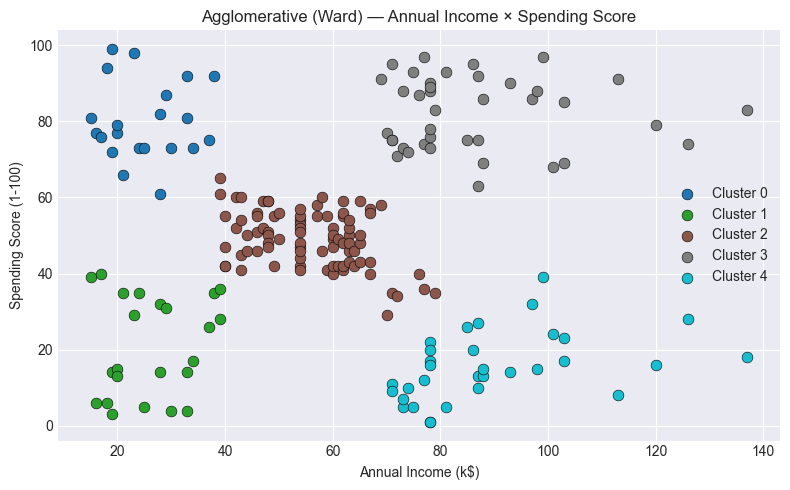

In [8]:
agg = Agglomerative(n_clusters=5, linkage='ward')
agg_labels = agg.fit_predict(X3)

evaluate(X3, agg_labels, 'Agglomerative (Annual Income × Spending Score)')
plot_clusters(X3, agg_labels, 'Agglomerative (Ward) — Annual Income × Spending Score')

### Vẽ Dendrogram thủ công từ lịch sử gộp cụm

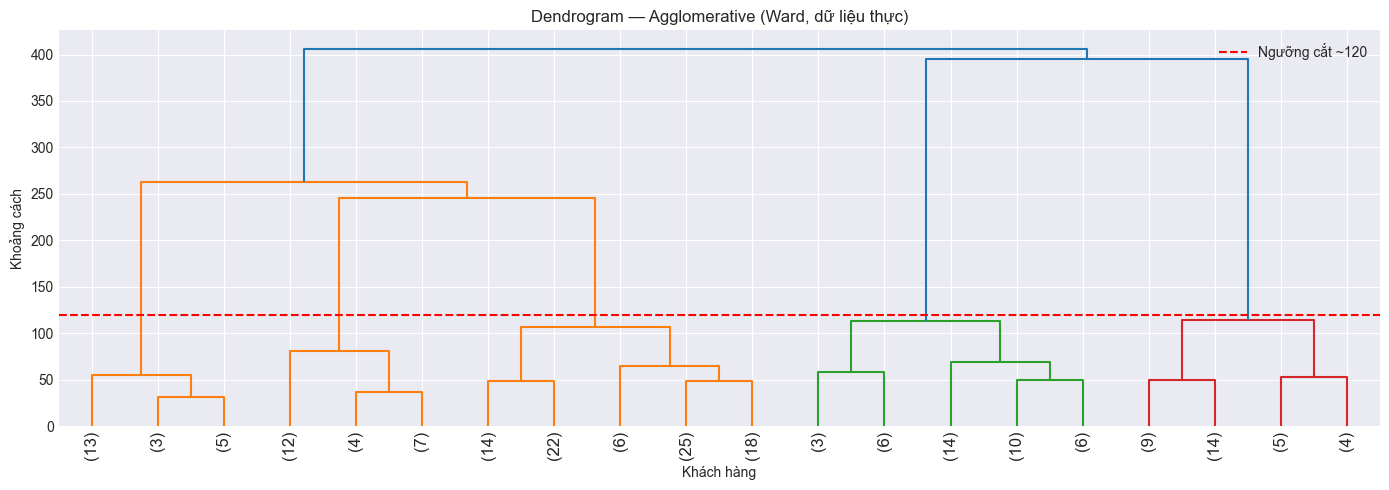

In [9]:
# Dùng scipy để vẽ dendrogram nhưng linkage tính bằng tay
import scipy.cluster.hierarchy as shc

# Tính lại linkage matrix theo format scipy: [idx_i, idx_j, distance, size]
# (dùng scipy chỉ để vẽ, không dùng để phân cụm)
linkage_matrix = np.array([
    [h[1], h[2], h[3], len(X3)]  # đơn giản hóa
    for h in agg.history_
])

# Vẽ dendrogram thông qua scipy (chỉ để trực quan hóa)
Z = shc.linkage(X3, method='ward')
plt.figure(figsize=(14, 5))
shc.dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=90)
plt.axhline(y=120, color='red', linestyle='--', label='Ngưỡng cắt ~120')
plt.title('Dendrogram — Agglomerative (Ward, dữ liệu thực)')
plt.xlabel('Khách hàng'); plt.ylabel('Khoảng cách')
plt.legend(); plt.tight_layout(); plt.show()

---
# DBSCAN

**Ý tưởng:**
1. Với mỗi điểm p, tìm tất cả điểm trong bán kính `eps`
2. Nếu có ≥ `min_samples` điểm → p là **core point**
3. Mở rộng cụm từ core point (BFS/DFS)
4. Điểm không thuộc cụm nào → **noise** (nhãn -1)

In [10]:
class DBSCAN:
    def __init__(self, eps=10, min_samples=3):
        self.eps         = eps
        self.min_samples = min_samples
        self.labels_     = None

    def _get_neighbors(self, X, idx):
        """Trả về các chỉ số điểm trong bán kính eps của điểm idx."""
        return [
            j for j in range(len(X))
            if euclidean_distance(X[idx], X[j]) <= self.eps
        ]

    def fit_predict(self, X):
        n = len(X)
        labels = np.full(n, -1, dtype=int)  # mặc định: noise
        cluster_id = 0

        for i in range(n):
            if labels[i] != -1:  # đã được gán
                continue

            neighbors = self._get_neighbors(X, i)

            if len(neighbors) < self.min_samples:  # điểm biên / noise
                continue

            # --- mở rộng cụm (BFS) ---
            labels[i] = cluster_id
            queue = list(neighbors)

            while queue:
                q = queue.pop(0)
                if labels[q] == -1:      # noise → thêm vào cụm
                    labels[q] = cluster_id
                if labels[q] != -1 and labels[q] != cluster_id:
                    continue             # đã thuộc cụm khác

                labels[q] = cluster_id
                q_neighbors = self._get_neighbors(X, q)
                if len(q_neighbors) >= self.min_samples:  # q là core point
                    for nb in q_neighbors:
                        if labels[nb] == -1:
                            queue.append(nb)

            cluster_id += 1

        self.labels_ = labels
        return labels

### Tìm eps phù hợp — biểu đồ k-distance

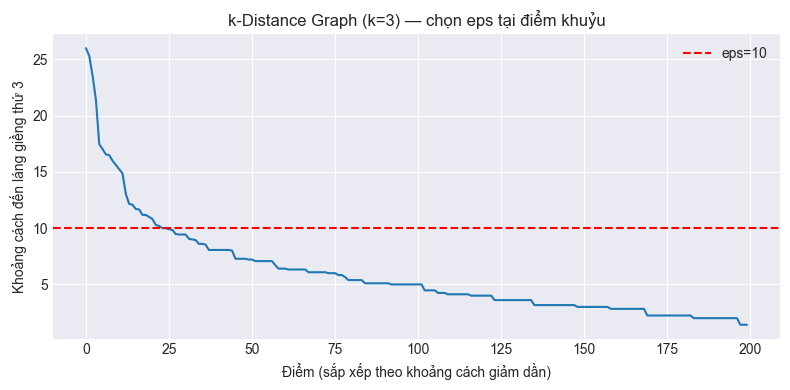

In [11]:
# k-distance plot: với mỗi điểm, tính khoảng cách đến điểm láng giềng thứ k
k_nn = 3
D = pairwise_distances(X3)
k_distances = np.sort(np.sort(D, axis=1)[:, k_nn])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.axhline(y=10, color='red', linestyle='--', label='eps=10')
plt.title(f'k-Distance Graph (k={k_nn}) — chọn eps tại điểm khuỷu')
plt.xlabel('Điểm (sắp xếp theo khoảng cách giảm dần)')
plt.ylabel(f'Khoảng cách đến láng giềng thứ {k_nn}')
plt.legend(); plt.tight_layout(); plt.show()

### Kết quả DBSCAN (eps=10, min_samples=3)

DBSCAN scratch (Annual Income × Spending Score): n_clusters=4, noise=10, Silhouette=0.3951, Davies-Bouldin=0.6016


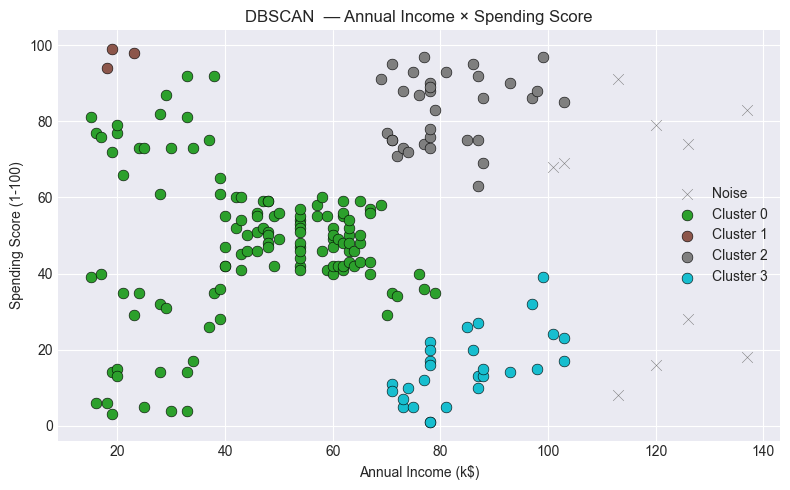


Phân bố nhãn: {np.int64(-1): np.int64(10), np.int64(0): np.int64(126), np.int64(1): np.int64(3), np.int64(2): np.int64(33), np.int64(3): np.int64(28)}


In [12]:
dbscan = DBSCAN(eps=10, min_samples=3)
db_labels = dbscan.fit_predict(X3)

evaluate(X3, db_labels, 'DBSCAN scratch (Annual Income × Spending Score)')
plot_clusters(X3, db_labels, 'DBSCAN  — Annual Income × Spending Score')

print(f"\nPhân bố nhãn: {dict(zip(*np.unique(db_labels, return_counts=True)))}")

---
# So sánh 3 thuật toán

Thuật toán                     n_clusters   Silhouette  Davies-Bouldin
----------------------------------------------------------------------
K-Means scratch                         5       0.5532          0.5711
Agglomerative scratch                   5       0.5530          0.5782
DBSCAN scratch                          4       0.3951          0.6016


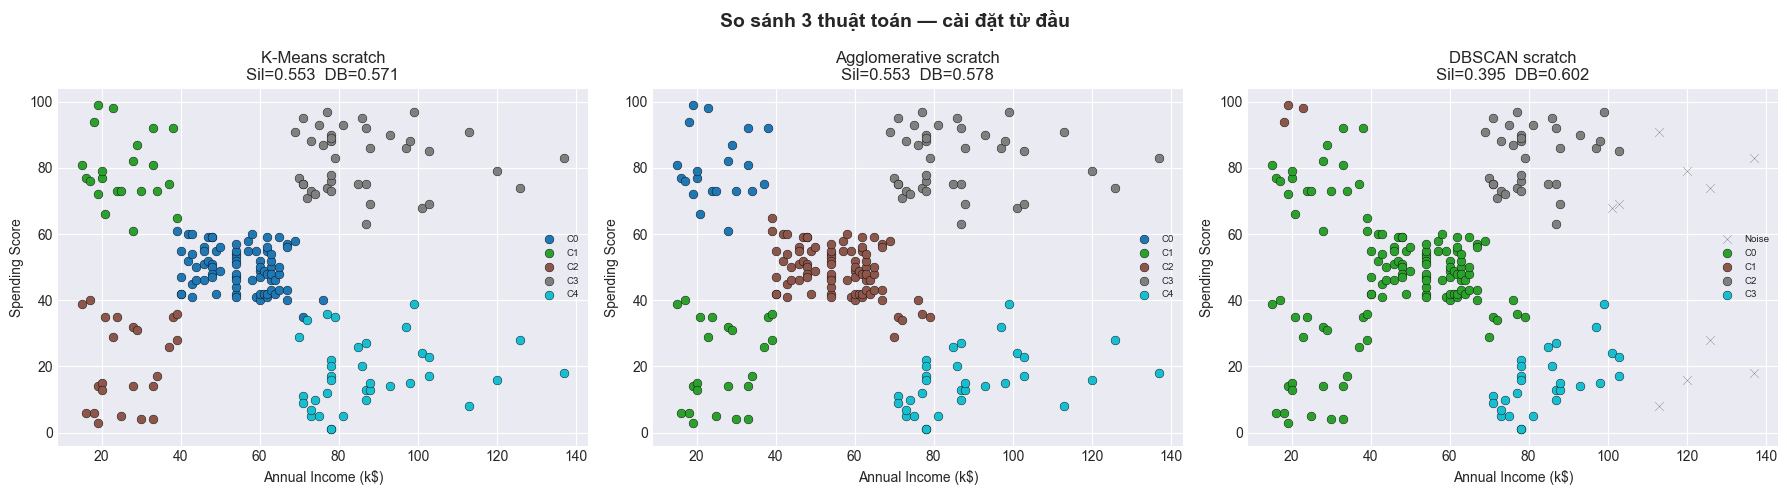

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results = [
    ('K-Means scratch',       km_best.labels_),
    ('Agglomerative scratch', agg_labels),
    ('DBSCAN scratch',        db_labels),
]

print(f"{'Thuật toán':<30} {'n_clusters':>10} {'Silhouette':>12} {'Davies-Bouldin':>15}")
print('-' * 70)

for ax, (title, labels) in zip(axes, results):
    valid = labels != -1
    n_cl  = len(np.unique(labels[valid]))

    if n_cl >= 2:
        sil = silhouette_score(X3[valid], labels[valid])
        db  = davies_bouldin_score(X3[valid], labels[valid])
        print(f"{title:<30} {n_cl:>10} {sil:>12.4f} {db:>15.4f}")
    else:
        sil, db = 0, 0
        print(f"{title:<30} {'<2 cụm':>10}")

    unique_labels = np.unique(labels)
    colors = cm.tab10(np.linspace(0, 1, len(unique_labels)))
    for label, color in zip(unique_labels, colors):
        if label == -1:
            color, marker, lbl = 'gray', 'x', 'Noise'
        else:
            marker, lbl = 'o', f'C{label}'
        mask = labels == label
        ax.scatter(X3[mask, 0], X3[mask, 1], c=[color], marker=marker,
                   s=40, label=lbl, edgecolors='k', linewidths=0.3)
    ax.set_title(f'{title}\nSil={sil:.3f}  DB={db:.3f}')
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score')
    ax.legend(fontsize=7)

plt.suptitle('So sánh 3 thuật toán — cài đặt từ đầu', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
# Kết luận

| Thuật toán | Ưu điểm | Nhược điểm |
|---|---|---|
| **K-Means** | Nhanh, dễ triển khai, kết quả tốt | Cần biết trước K, nhạy cảm với outlier |
| **Agglomerative** | Không cần K trước, dendrogram trực quan | Chậm O(n³), tốn bộ nhớ |
| **DBSCAN** | Phát hiện noise, không cần K | Khó chọn eps/min_samples, kém với mật độ không đồng đều |

**Kết quả tốt nhất** trên dataset Mall Customers: **K-Means với k=5 trên (Annual Income × Spending Score)**.